<a href="https://colab.research.google.com/github/Clinton1029/Heart_Failure/blob/main/Heart_Failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Failure Prediction Using Machine Learning

## Introduction

Heart failure is a chronic cardiovascular condition in which the heart is unable to pump blood efficiently to meet the body's needs. It is one of the leading causes of hospitalization and mortality worldwide, affecting millions of people every year. Early identification of patients who are at high risk of death allows healthcare professionals to make timely medical interventions, improve treatment strategies, and increase patient survival rates.

Machine learning has become an important tool in healthcare by enabling computers to learn patterns from historical patient data and make predictions about future outcomes. By analyzing clinical characteristics such as age, serum creatinine level, ejection fraction, diabetes status, blood pressure, and other medical indicators, machine learning models can assist clinicians in predicting whether a patient is likely to survive after being diagnosed with heart failure.

In this project, several supervised machine learning algorithms will be developed and evaluated using the Heart Failure Clinical Records Dataset. The objective is to build a classification model capable of predicting whether a patient will survive or die during the follow-up period based on their clinical records.

# Problem Statement

Heart failure is associated with high mortality rates despite advances in medical treatment. Healthcare providers often rely on multiple clinical measurements to determine the severity of a patient's condition, making prognosis a complex task. Identifying patients who are at greater risk of death using traditional methods alone can be challenging due to the large number of contributing clinical factors.

Machine learning techniques provide an opportunity to analyze these clinical variables simultaneously and discover patterns that may not be immediately obvious through conventional statistical analysis. Developing an accurate predictive model can assist healthcare professionals in making informed clinical decisions, prioritizing high-risk patients, and improving patient management.

Therefore, this project seeks to develop and evaluate machine learning models capable of predicting heart failure outcomes using patient clinical data.

# Project Workflow

The project will follow these steps:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Preparation
5. Feature Selection
6. Split the Dataset into Training and Testing Sets
7. Choose the Machine Learning Model
8. Train the Machine Learning Model
9. Make Predictions
10. Evaluate Model Performance
11. Predict Heart Failure Outcome for New Patients

## 1. Import Required Libraries


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml


## 2. Load the Dataset

In [6]:
# Fetch the Heart Failure dataset

heart= fetch_openml(data_id=43682, as_frame=True)

df = heart_disease.frame

# Convert to a pandas DataFrame
df = heart.frame

# Display the first five rows
df.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Display the First Five Rows


In [8]:
df.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


### 3.2 Display the Last Five Rows


In [9]:
df.tail()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
1185,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,1.0
1186,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,1.0
1187,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0
1188,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0
1189,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0


### 3.3 Dataset Dimensions


In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1190, 12)


### 3.4 Dataset Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   float64
 1   sex                  1190 non-null   float64
 2   chest_pain_type      1190 non-null   float64
 3   resting_bp_s         1190 non-null   float64
 4   cholesterol          1190 non-null   float64
 5   fasting_blood_sugar  1190 non-null   float64
 6   resting_ecg          1190 non-null   float64
 7   max_heart_rate       1190 non-null   float64
 8   exercise_angina      1190 non-null   float64
 9   oldpeak              1190 non-null   float64
 10  ST_slope             1190 non-null   float64
 11  target               1190 non-null   float64
dtypes: float64(12)
memory usage: 111.7 KB


### 3.5 Summary Statistics

In [12]:
df.describe()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


### 3.5 Check Missing Values


In [13]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp_s,0
cholesterol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_angina,0
oldpeak,0


###### There is no missing values

### 3.6 Check Duplicate Records

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 272


###### There are 272 Duplicated rows and Therefore Data cleaning is required to remove Duplicate

### 3.8 Distribution of the Target Variable

The target variable represents whether a patient has heart disease. Examining its distribution helps determine whether the dataset is balanced or imbalanced.

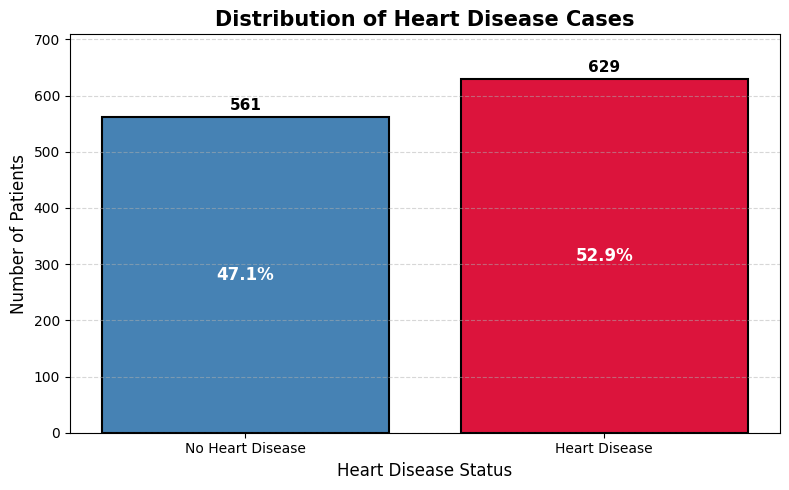

In [21]:


# Count target classes
target_counts = df["target"].value_counts().sort_index()
total = len(df)

# Create figure
plt.figure(figsize=(8, 5))

# Create bars
bars = plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_counts,
    color=["steelblue", "crimson"],
    edgecolor="black",
    linewidth=1.5
)

# Add labels
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100

    # Percentage inside the bar
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height / 2,
        f"{percentage:.1f}%",
        ha='center',
        va='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

    # Count above the bar
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 8,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

# Customize the plot
plt.title("Distribution of Heart Disease Cases", fontsize=15, fontweight='bold')
plt.xlabel("Heart Disease Status", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Add some space above the bars
plt.ylim(0, max(target_counts) + 80)

# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

###### Interpretation of the Target Variable Distribution

The distribution of the target variable indicates that the dataset contains patients from both classes. Specifically, **629 patients were diagnosed with heart disease**, while **561 patients did not have heart disease**. This shows that the dataset is relatively balanced, with only a slight difference between the two classes.
